# Comparación: Simulación vs Realidad

Comparación entre las variables del **historial de simulación** (`data/ai-uponor_smatrix-alcorcon-lab_c7rqx7hm_history.csv`) y las variables de los CSV del **monitor** en `data/monitor/` (observations, actions, infos, rewards).

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
HISTORY_CSV = DATA_DIR / "ai-uponor_smatrix-alcorcon-lab_c7rqx7hm_history.csv"
MONITOR_DIR = DATA_DIR / "monitor"


## 1. Carga de datos

In [36]:
df_history = pd.read_csv(HISTORY_CSV)
print("Historial (simulación):", df_history.shape)
df_history.head(2)

Historial (simulación): (41, 65)


,_timestamp,info/valve_f1_secondary_bathroom,info/energy_penalty,observation/air_humidity_f0_bathroom,action/valve_f0_bathroom,info/comfort_threshold,reward,info/t_supply,observation/outdoor_humidity,observation/air_temperature_f1_bed3,...,observation/direct_solar_radiation,observation/air_temperature_f0_livroom-kitchen,observation/air_temperature_f1_secondary_bathroom,_step,observation/air_humidity_f0_livroom-kitchen,observation/setpoint_f0_bathroom,observation/diffuse_solar_radiation,info/total_power_demand,action/valve_f1_bed1,batch/comfort_violation_time(%)
0,1.772627e+09,1,-308.4,52,0.070579,1,-1.453624,33.220539,48,21.388889,...,258.875,21.833334,20.944445,2,48,19.5,565.049988,308.4,-0.135216,NaN
1,1.772628e+09,1,-746.0,52,0.090186,1,-1.832594,33.139458,48,21.500000,...,258.875,21.944445,21.000000,3,48,19.5,565.049988,746.0,-0.140853,NaN


In [37]:
df_obs = pd.read_csv(MONITOR_DIR / "observations.csv")
df_actions = pd.read_csv(MONITOR_DIR / "agent_actions.csv")
df_infos = pd.read_csv(MONITOR_DIR / "infos.csv")
df_rewards = pd.read_csv(MONITOR_DIR / "rewards.csv")
df_sim_actions = pd.read_csv(MONITOR_DIR / "simulated_actions.csv")

print("Monitor - observations:", df_obs.shape)
print("Monitor - agent_actions:", df_actions.shape)
print("Monitor - infos:", df_infos.shape)
print("Monitor - rewards:", df_rewards.shape)
print("Monitor - simulated_actions:", df_sim_actions.shape)

Monitor - observations: (8736, 62)
Monitor - agent_actions: (8735, 8)
Monitor - infos: (8736, 10)
Monitor - rewards: (8735, 1)
Monitor - simulated_actions: (8735, 8)


## 2. Variables por fuente

Extraemos y agrupamos las variables del history por prefijo (observation, action, info) y las comparamos con las columnas del monitor.

In [38]:
def get_history_vars_by_prefix(df):
    """Agrupa columnas del history por prefijo (observation/, action/, info/)."""
    groups = {"observation": [], "action": [], "info": [], "other": []}
    for c in df.columns:
        if c.startswith("observation/"):
            groups["observation"].append(c.replace("observation/", ""))
        elif c.startswith("action/"):
            groups["action"].append(c.replace("action/", ""))
        elif c.startswith("info/"):
            groups["info"].append(c.replace("info/", ""))
        else:
            groups["other"].append(c)
    return groups

history_vars = get_history_vars_by_prefix(df_history)
print("Variables en history (simulación):")
for k, v in history_vars.items():
    print(f"  {k}: {len(v)} vars")
print("\nObservation (history):", sorted(history_vars["observation"])[:15], "...")
print("\nAction (history):", history_vars["action"])
print("\nInfo (history):", sorted(history_vars["info"])[:12], "...")

Variables en history (simulación):
  observation: 35 vars
  action: 8 vars
  info: 17 vars
  other: 5 vars

Observation (history): ['air_humidity_f0_bathroom', 'air_humidity_f0_livroom-kitchen', 'air_humidity_f1_bed1', 'air_humidity_f1_bed2', 'air_humidity_f1_bed3', 'air_humidity_f1_main_bathroom', 'air_humidity_f1_secondary_bathroom', 'air_temperature_f0_bathroom', 'air_temperature_f0_livroom-kitchen', 'air_temperature_f1_bed1', 'air_temperature_f1_bed2', 'air_temperature_f1_bed3', 'air_temperature_f1_main_bathroom', 'air_temperature_f1_secondary_bathroom', 'day_cos'] ...

Action (history): ['valve_f0_bathroom', 'valve_f1_secondary_bathroom', 'valve_f1_main_bathroom', 'valve_f0_livroom-kitchen', 'valve_f1_bed3', 'valve_f1_bed2', 't_supply', 'valve_f1_bed1']

Info (history): ['comfort_penalty', 'comfort_term', 'comfort_threshold', 'energy_penalty', 'energy_term', 'reward_weight', 't_supply', 'timestep', 'total_power_demand', 'total_temperature_violation', 'valve_f0_bathroom', 'valve_f0

In [39]:
print("Variables en monitor:")
print("  observations.csv:", list(df_obs.columns))
print("  agent_actions.csv:", list(df_actions.columns))
print("  infos.csv:", list(df_infos.columns))
print("  rewards.csv:", list(df_rewards.columns))

Variables en monitor:
  observations.csv: ['month_cos', 'month_sin', 'day_cos', 'day_sin', 'hour_cos', 'hour_sin', 'outdoor_temperature', 'outdoor_humidity', 'wind_speed', 'wind_direction', 'diffuse_solar_radiation', 'direct_solar_radiation', 'air_temperature_f0_living-kitchen', 'air_temperature_f0_bathroom-lobby', 'air_temperature_f1_bedroom1', 'air_temperature_f1_bedroom2', 'air_temperature_f1_bedroom3', 'air_temperature_f1_bathroom-corridor', 'air_temperature_f1_bathroom-dressing', 'air_humidity_f0_living-kitchen', 'air_humidity_f0_bathroom-lobby', 'air_humidity_f1_bedroom1', 'air_humidity_f1_bedroom2', 'air_humidity_f1_bedroom3', 'air_humidity_f1_bathroom-corridor', 'air_humidity_f1_bathroom-dressing', 'heating_setpoint_f0_living-kitchen', 'heating_setpoint_f0_bathroom-lobby', 'heating_setpoint_f1_bedroom1', 'heating_setpoint_f1_bedroom2', 'heating_setpoint_f1_bedroom3', 'heating_setpoint_f1_bathroom-corridor', 'heating_setpoint_f1_bathroom-dressing', 'radiant_hvac_outlet_temperatu

## 3. Mapeo de nombres: History (smatrix) ↔ Monitor

El history usa nombres tipo `livroom-kitchen`, `bed1`, `main_bathroom`, etc. El monitor usa `living-kitchen`, `bedroom1`, `bathroom-corridor`, etc. Además el history tiene `heat_pump_*` y el monitor `heat_source_*` y `radiant_hvac_*`.

In [40]:
# Mapeo: nombre en history (sin prefijo) -> nombre en monitor (observations/actions)
OBS_MAPPING = {
    "air_temperature_f0_bathroom": "air_temperature_f0_bathroom-lobby",
    "air_temperature_f0_livroom-kitchen": "air_temperature_f0_living-kitchen",
    "air_temperature_f1_bed1": "air_temperature_f1_bedroom1",
    "air_temperature_f1_bed2": "air_temperature_f1_bedroom2",
    "air_temperature_f1_bed3": "air_temperature_f1_bedroom3",
    "air_temperature_f1_main_bathroom": "air_temperature_f1_bathroom-corridor",
    "air_temperature_f1_secondary_bathroom": "air_temperature_f1_bathroom-dressing",
    "air_humidity_f0_bathroom": "air_humidity_f0_bathroom-lobby",
    "air_humidity_f0_livroom-kitchen": "air_humidity_f0_living-kitchen",
    "air_humidity_f1_bed1": "air_humidity_f1_bedroom1",
    "air_humidity_f1_bed2": "air_humidity_f1_bedroom2",
    "air_humidity_f1_bed3": "air_humidity_f1_bedroom3",
    "air_humidity_f1_main_bathroom": "air_humidity_f1_bathroom-corridor",
    "air_humidity_f1_secondary_bathroom": "air_humidity_f1_bathroom-dressing",
    "setpoint_f0_bathroom": "heating_setpoint_f0_bathroom-lobby",
    "setpoint_f0_livroom-kitchen": "heating_setpoint_f0_living-kitchen",
    "setpoint_f1_bed1": "heating_setpoint_f1_bedroom1",
    "setpoint_f1_bed2": "heating_setpoint_f1_bedroom2",
    "setpoint_f1_bed3": "heating_setpoint_f1_bedroom3",
    "setpoint_f1_main_bathroom": "heating_setpoint_f1_bathroom-corridor",
    "setpoint_f1_secondary_bathroom": "heating_setpoint_f1_bathroom-dressing",
    "outdoor_temperature": "outdoor_temperature",
    "outdoor_humidity": "outdoor_humidity",
    "wind_speed": "wind_speed",
    "wind_direction": "wind_direction",
    "direct_solar_radiation": "direct_solar_radiation",
    "diffuse_solar_radiation": "diffuse_solar_radiation",
    "month_cos": "month_cos", "month_sin": "month_sin", "day_cos": "day_cos", "day_sin": "day_sin",
    "hour_cos": "hour_cos", "hour_sin": "hour_sin",
    "heat_pump_load_side_outlet_temp": "heat_source_load_side_outlet_temp",
    "heat_pump_electricity_rate": "heat_source_electricity_rate",
}

# Acciones: history usa valve_* y t_supply; monitor usa flow_rate_* y water_temperature
ACTION_MAPPING = {
    "valve_f0_bathroom": "flow_rate_f0_bathroom-lobby",
    "valve_f0_livroom-kitchen": "flow_rate_f0_living-kitchen",
    "valve_f1_bed1": "flow_rate_f1_bedroom1",
    "valve_f1_bed2": "flow_rate_f1_bedroom2",
    "valve_f1_bed3": "flow_rate_f1_bedroom3",
    "valve_f1_main_bathroom": "flow_rate_f1_bathroom-corridor",
    "valve_f1_secondary_bathroom": "flow_rate_f1_bathroom-dressing",
    "t_supply": "water_temperature",
}

INFO_MAPPING = {
    "energy_penalty": "energy_penalty",
    "comfort_penalty": "comfort_penalty",
    "comfort_threshold": "comfort_threshold",
    "total_power_demand": "total_power_demand",
    "total_temperature_violation": "total_temperature_violation",
    "energy_term": "energy_term",
    "comfort_term": "comfort_term",
}

print("Observaciones mapeadas (history -> monitor):", len(OBS_MAPPING))
print("Acciones mapeadas:", len(ACTION_MAPPING))
print("Info mapeadas:", len(INFO_MAPPING))

Observaciones mapeadas (history -> monitor): 35
Acciones mapeadas: 8
Info mapeadas: 7


## 4. Variables solo en History vs solo en Monitor

In [41]:
history_obs_set = set(history_vars["observation"])
history_act_set = set(history_vars["action"])
history_info_set = set(history_vars["info"])
monitor_obs_cols = set(df_obs.columns)
monitor_act_cols = set(df_actions.columns)
monitor_info_cols = set(df_infos.columns)

obs_in_both = set(OBS_MAPPING.keys()) & history_obs_set
obs_monitor_mapped = set(OBS_MAPPING.values()) & monitor_obs_cols
only_history_obs = history_obs_set - set(OBS_MAPPING.keys())
only_monitor_obs = monitor_obs_cols - set(OBS_MAPPING.values())

print("Observaciones:")
print("  En ambos (mapeadas):", len(obs_in_both))
print("  Solo en history:", sorted(only_history_obs))
print("  Solo en monitor (ejemplos):", sorted(only_monitor_obs)[:20], "..." if len(only_monitor_obs) > 20 else "")

act_in_both = set(ACTION_MAPPING.keys()) & history_act_set
only_history_act = history_act_set - set(ACTION_MAPPING.keys())
only_monitor_act = monitor_act_cols - set(ACTION_MAPPING.values())
print("\nAcciones:")
print("  En ambos (mapeadas):", len(act_in_both))
print("  Solo en history:", only_history_act)
print("  Solo en monitor:", only_monitor_act)

Observaciones:
  En ambos (mapeadas): 35
  Solo en history: []
  Solo en monitor (ejemplos): ['crf', 'flow_rate_f0_bathroom-lobby', 'flow_rate_f0_living-kitchen', 'flow_rate_f1_bathroom-corridor', 'flow_rate_f1_bathroom-dressing', 'flow_rate_f1_bedroom1', 'flow_rate_f1_bedroom2', 'flow_rate_f1_bedroom3', 'heat_source_load_side_heat_transfer_rate', 'heat_source_load_side_inlet_temp', 'heat_source_load_side_mass_flow_rate', 'plr_current', 'radiant_hvac_inlet_temperature_f0_bathroom-lobby', 'radiant_hvac_inlet_temperature_f0_living-kitchen', 'radiant_hvac_inlet_temperature_f1_bathroom-corridor', 'radiant_hvac_inlet_temperature_f1_bathroom-dressing', 'radiant_hvac_inlet_temperature_f1_bedroom1', 'radiant_hvac_inlet_temperature_f1_bedroom2', 'radiant_hvac_inlet_temperature_f1_bedroom3', 'radiant_hvac_outlet_temperature_f0_bathroom-lobby'] ...

Acciones:
  En ambos (mapeadas): 8
  Solo en history: set()
  Solo en monitor: set()


## 5. Comparación temporal (mismo periodo de tiempo)

Alineamos ambas series por **tiempo**: el history tiene `_timestamp` (Unix) y el monitor tiene `month`, `day`, `hour` en infos. Obtenemos el periodo común (por hora) y comparamos solo en ese intervalo.

In [42]:
# --- History: tiempo desde _timestamp ---
df_history = df_history.copy()
df_history["_datetime"] = pd.to_datetime(df_history["_timestamp"], unit="s")
df_history["_month"] = df_history["_datetime"].dt.month
df_history["_day"] = df_history["_datetime"].dt.day
df_history["_hour"] = df_history["_datetime"].dt.hour
df_history["_time_key"] = (
    df_history["_month"].astype(str) + "-"
    + df_history["_day"].astype(str) + "-"
    + df_history["_hour"].astype(str)
)

# --- Monitor: tiempo desde infos (month, day, hour); año del history ---
year_ref = df_history["_datetime"].iloc[0].year
df_infos = df_infos.copy()
df_infos["_datetime"] = pd.to_datetime(
    dict(
        year=year_ref,
        month=df_infos["month"],
        day=df_infos["day"],
        hour=df_infos["hour"],
    )
)
df_infos["_time_key"] = (
    df_infos["month"].astype(str) + "-"
    + df_infos["day"].astype(str) + "-"
    + df_infos["hour"].astype(str)
)

# --- Claves (month-day-hour) comunes ---
keys_history = set(df_history["_time_key"].dropna())
keys_monitor = set(df_infos["_time_key"].dropna())
common_keys = sorted(keys_history & keys_monitor)

# Filtrar a filas que pertenecen a horas comunes
hist_mask = df_history["_time_key"].isin(common_keys)
mon_mask = df_infos["_time_key"].isin(common_keys)

# Agregar por hora: una fila por time_key (media en esa hora)
hist_by_hour = df_history.loc[hist_mask].groupby("_time_key", sort=True)
mon_infos_by_hour = df_infos.loc[mon_mask].groupby("_time_key", sort=True)

# Índices de monitor por hora (para tomar filas de df_obs, df_actions, df_rewards)
# Usamos la primera fila de cada grupo para tener un índice representativo por hora
mon_first_idx = mon_infos_by_hour.apply(lambda g: g.index[0]).reindex(common_keys).dropna()
# Mantener orden de common_keys
mon_first_idx = mon_first_idx.reindex(common_keys).dropna().astype(int).tolist()

# History agregado por hora (media): una fila por common_key en orden
df_history_hour = hist_by_hour.mean(numeric_only=True)
df_history_hour = df_history_hour.reindex(common_keys)

n_compare = len(common_keys)
# Eje temporal: datetime de la primera aparición de cada key en history (para el eje x)
first_datetime_per_key = (
    df_history.loc[hist_mask]
    .groupby("_time_key", sort=True)["_datetime"]
    .first()
    .reindex(common_keys)
)
time_axis = first_datetime_per_key.values
idx = np.arange(n_compare)

# Monitor agregado por hora (media) para las mismas claves, para comparación justa
def monitor_agg_by_key(df, keys, infos_time_key, infos_mask):
    """Agrega df por _time_key usando índices de infos; devuelve DataFrame con una fila por key en keys."""
    rows = []
    for k in keys:
        cond = infos_mask & (infos_time_key == k)
        ii = cond.index[cond].tolist()
        ii = [i for i in ii if i in df.index]
        if ii:
            rows.append(df.loc[ii].mean(numeric_only=True))
        else:
            rows.append(pd.Series(dtype=float))
    return pd.DataFrame(rows, index=keys)

df_obs_hour = monitor_agg_by_key(df_obs, common_keys, df_infos["_time_key"], mon_mask)
df_infos_hour = monitor_agg_by_key(df_infos, common_keys, df_infos["_time_key"], mon_mask)
# df_actions y df_rewards pueden tener una fila menos; alineamos por posición
n_act = min(len(df_actions), len(df_infos))
df_actions["_time_key"] = df_infos["_time_key"].iloc[:n_act].values
df_rewards["_time_key"] = df_infos["_time_key"].iloc[:n_act].values
mon_mask_act = np.zeros(len(df_infos), dtype=bool)
mon_mask_act[:n_act] = mon_mask.values[:n_act]
df_actions_hour = monitor_agg_by_key(
    df_actions, common_keys, df_infos["_time_key"].iloc[:n_act], pd.Series(mon_mask_act[:n_act])
)
df_rewards_hour = monitor_agg_by_key(
    df_rewards, common_keys, df_infos["_time_key"].iloc[:n_act], pd.Series(mon_mask_act[:n_act])
)

print(f"History: {len(df_history)} filas, Monitor: {len(df_infos)} filas.")
print(f"Claves (month-day-hour) en history: {len(keys_history)}, en monitor: {len(keys_monitor)}.")
print(f"Claves comunes (mismo periodo): {len(common_keys)} -> comparamos {n_compare} horas.")
if n_compare > 0:
    print(f"Periodo: {first_datetime_per_key.iloc[0]} a {first_datetime_per_key.iloc[-1]}.")

History: 41 filas, Monitor: 8736 filas.
Claves (month-day-hour) en history: 21, en monitor: 4368.
Claves comunes (mismo periodo): 21 -> comparamos 21 horas.
Periodo: 2026-03-04 12:15:48.236082792 a 2026-03-05 08:17:47.552323103.


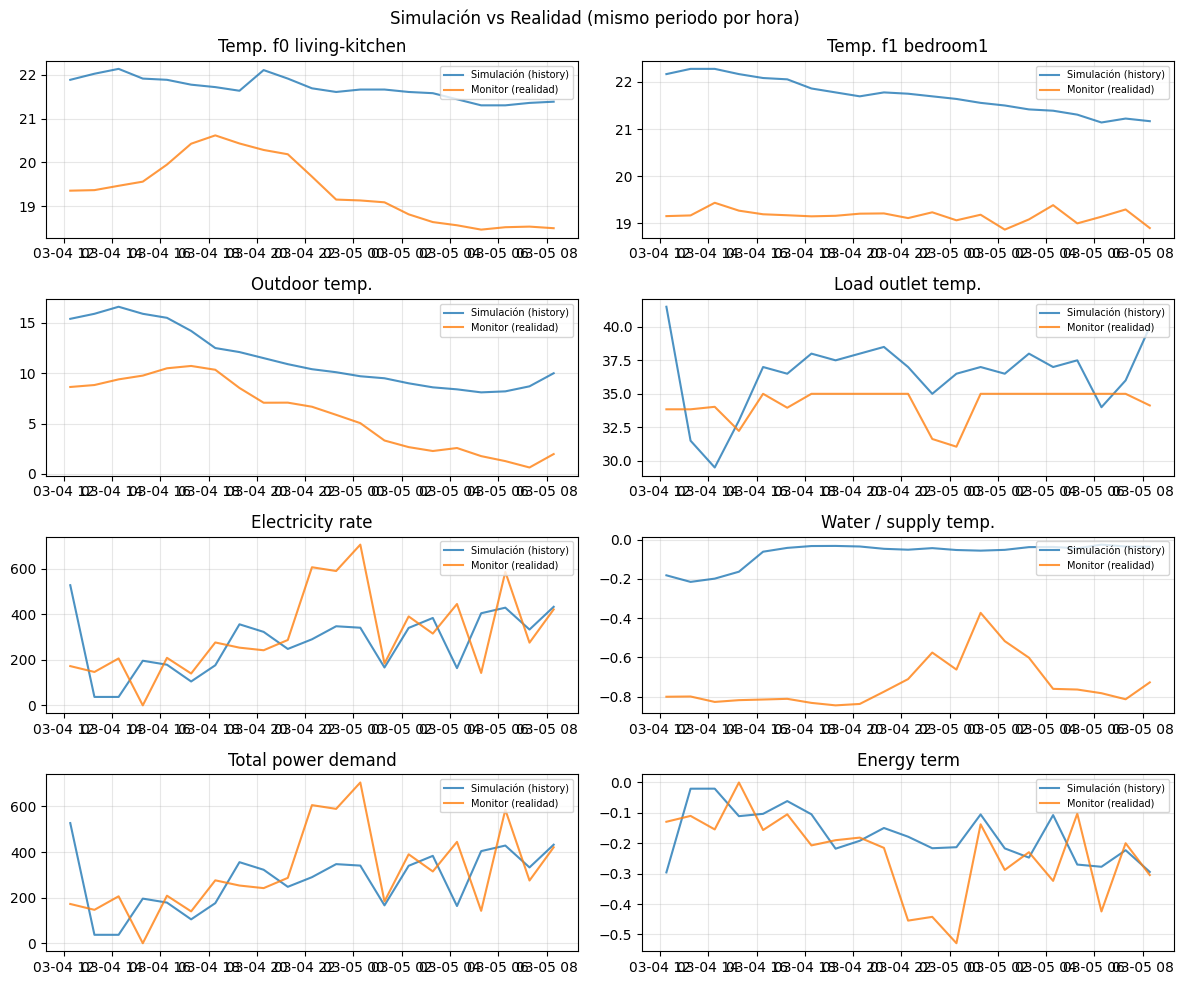

In [43]:
def get_history_col(df, prefix, name):
    col = f"{prefix}/{name}"
    return df[col].values if col in df.columns else None

# Usar datos agregados por hora (alineados en el mismo periodo)
def get_monitor_series_hour(prefix, mon_name):
    if prefix == "observation" and mon_name in df_obs_hour.columns:
        return df_obs_hour[mon_name].values
    if prefix == "action" and mon_name in df_actions_hour.columns:
        return df_actions_hour[mon_name].values
    if prefix == "info" and mon_name in df_infos_hour.columns:
        return df_infos_hour[mon_name].values
    return None

fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes = axes.flatten()

vars_to_plot = [
    ("observation", "air_temperature_f0_livroom-kitchen", "air_temperature_f0_living-kitchen", "Temp. f0 living-kitchen"),
    ("observation", "air_temperature_f1_bed1", "air_temperature_f1_bedroom1", "Temp. f1 bedroom1"),
    ("observation", "outdoor_temperature", "outdoor_temperature", "Outdoor temp."),
    ("observation", "heat_pump_load_side_outlet_temp", "heat_source_load_side_outlet_temp", "Load outlet temp."),
    ("observation", "heat_pump_electricity_rate", "heat_source_electricity_rate", "Electricity rate"),
    ("action", "t_supply", "water_temperature", "Water / supply temp."),
    ("info", "total_power_demand", "total_power_demand", "Total power demand"),
    ("info", "energy_term", "energy_term", "Energy term"),
]

x_axis = time_axis if n_compare > 0 and not (pd.isna(time_axis).any()) else idx

if n_compare == 0:
    for ax in axes:
        ax.set_visible(False)
    plt.suptitle("No hay periodo común (month-day-hour) entre history y monitor.", fontsize=12)
else:
    for ax, (prefix, hist_name, mon_name, title) in zip(axes, vars_to_plot):
        h_col = get_history_col(df_history_hour, prefix, hist_name)
        m_vals = get_monitor_series_hour(prefix, mon_name)
        if m_vals is None or len(m_vals) == 0:
            ax.set_visible(False)
            continue
        if h_col is not None:
            h_vals = np.asarray(h_col)[:n_compare]
            ax.plot(x_axis, h_vals, label="Simulación (history)", alpha=0.8)
        m_vals = np.asarray(m_vals)[:n_compare]
        ax.plot(x_axis, m_vals, label="Monitor (realidad)", alpha=0.8)
        ax.set_title(title)
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(True, alpha=0.3)
    plt.suptitle("Simulación vs Realidad (mismo periodo por hora)", fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Reward: history vs monitor

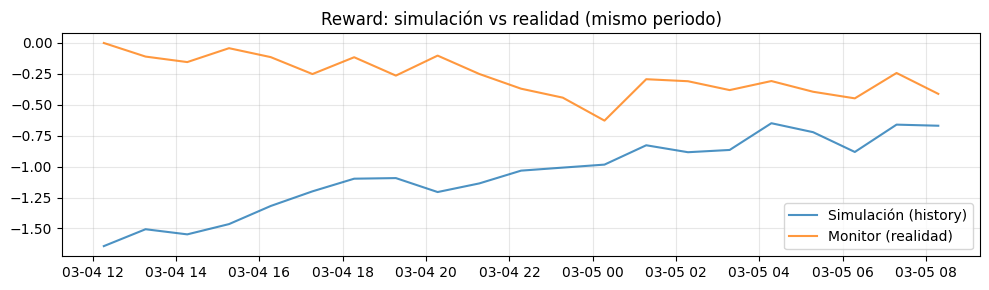

Reward - Media history: -1.0664357057973188 , Media monitor: -0.2681515612247747


In [44]:
if n_compare > 0 and "reward" in df_history_hour.columns and "reward" in df_rewards_hour.columns:
    r_history = np.asarray(df_history_hour["reward"].values)[:n_compare]
    r_monitor = np.asarray(df_rewards_hour["reward"].values)[:n_compare]
    x_axis_r = time_axis if not (pd.isna(time_axis).any()) else idx
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.plot(x_axis_r, r_history, label="Simulación (history)", alpha=0.8)
    ax.plot(x_axis_r, r_monitor, label="Monitor (realidad)", alpha=0.8)
    ax.set_title("Reward: simulación vs realidad (mismo periodo)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('Reward - Media history:', r_history.mean(), ', Media monitor:', r_monitor.mean())
else:
    print("No hay datos de reward alineados en el periodo común o n_compare = 0.")

## 7. Comparación de distribuciones (estadísticas por variable)

Para cada variable presente en ambos orígenes (simulación y monitor), comparamos **mínimo, máximo, media, desv. típica y percentiles** (25%, 50%, 75%) en el mismo periodo temporal (datos alineados por hora cuando hay periodo común).

In [45]:
def stats_series(s):
    """Mín, máx, media, std y percentiles de una serie numérica."""
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return {"min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p25": np.nan, "p50": np.nan, "p75": np.nan}
    return {
        "min": s.min(),
        "max": s.max(),
        "mean": s.mean(),
        "std": s.std(),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
    }

# Usar datos alineados por hora si hay periodo común; si no, series completas
use_aligned = n_compare > 0
if use_aligned:
    _hist_obs, _mon_obs = df_history_hour, df_obs_hour
    _hist_act, _mon_act = df_history_hour, df_actions_hour
    _hist_inf, _mon_inf = df_history_hour, df_infos_hour
else:
    _hist_obs, _mon_obs = df_history, df_obs
    _hist_act, _mon_act = df_history, df_actions
    _hist_inf, _mon_inf = df_history, df_infos

rows = []
for h_name, m_name in OBS_MAPPING.items():
    col_h = f"observation/{h_name}"
    if col_h not in _hist_obs.columns or m_name not in _mon_obs.columns:
        continue
    sh = _hist_obs[col_h]
    sm = _mon_obs[m_name]
    st_h = stats_series(sh)
    st_m = stats_series(sm)
    rows.append({
        "variable": m_name,
        "origen": "observation",
        "sim_min": st_h["min"], "sim_max": st_h["max"], "sim_mean": st_h["mean"], "sim_std": st_h["std"],
        "sim_p25": st_h["p25"], "sim_p50": st_h["p50"], "sim_p75": st_h["p75"],
        "mon_min": st_m["min"], "mon_max": st_m["max"], "mon_mean": st_m["mean"], "mon_std": st_m["std"],
        "mon_p25": st_m["p25"], "mon_p50": st_m["p50"], "mon_p75": st_m["p75"],
        "diff_mean": st_h["mean"] - st_m["mean"],
    })
for h_name, m_name in ACTION_MAPPING.items():
    col_h = f"action/{h_name}"
    if col_h not in _hist_act.columns or m_name not in _mon_act.columns:
        continue
    sh = _hist_act[col_h]
    sm = _mon_act[m_name]
    st_h = stats_series(sh)
    st_m = stats_series(sm)
    rows.append({
        "variable": m_name,
        "origen": "action",
        "sim_min": st_h["min"], "sim_max": st_h["max"], "sim_mean": st_h["mean"], "sim_std": st_h["std"],
        "sim_p25": st_h["p25"], "sim_p50": st_h["p50"], "sim_p75": st_h["p75"],
        "mon_min": st_m["min"], "mon_max": st_m["max"], "mon_mean": st_m["mean"], "mon_std": st_m["std"],
        "mon_p25": st_m["p25"], "mon_p50": st_m["p50"], "mon_p75": st_m["p75"],
        "diff_mean": st_h["mean"] - st_m["mean"],
    })
for h_name, m_name in INFO_MAPPING.items():
    col_h = f"info/{h_name}"
    if col_h not in _hist_inf.columns or m_name not in _mon_inf.columns:
        continue
    sh = _hist_inf[col_h]
    sm = _mon_inf[m_name]
    st_h = stats_series(sh)
    st_m = stats_series(sm)
    rows.append({
        "variable": m_name,
        "origen": "info",
        "sim_min": st_h["min"], "sim_max": st_h["max"], "sim_mean": st_h["mean"], "sim_std": st_h["std"],
        "sim_p25": st_h["p25"], "sim_p50": st_h["p50"], "sim_p75": st_h["p75"],
        "mon_min": st_m["min"], "mon_max": st_m["max"], "mon_mean": st_m["mean"], "mon_std": st_m["std"],
        "mon_p25": st_m["p25"], "mon_p50": st_m["p50"], "mon_p75": st_m["p75"],
        "diff_mean": st_h["mean"] - st_m["mean"],
    })

df_dist = pd.DataFrame(rows)
print("Datos usados:", "alineados por hora (mismo periodo)" if use_aligned else "series completas (sin alineación temporal)")
print("Variables comparadas:", len(df_dist))
df_dist

Datos usados: alineados por hora (mismo periodo)
Variables comparadas: 50


,variable,origen,sim_min,sim_max,sim_mean,sim_std,sim_p25,sim_p50,sim_p75,mon_min,mon_max,mon_mean,mon_std,mon_p25,mon_p50,mon_p75,diff_mean
0,air_temperature_f0_bathroom-lobby,observation,19.833334,20.500000,20.085979,0.185281,19.944445,20.083333,20.194444,19.185495,20.333075,19.656953,0.367940,19.272457,19.693382,19.954890,0.429026
1,air_temperature_f0_living-kitchen,observation,21.305556,22.138888,21.698413,0.251429,21.583333,21.666666,21.888889,18.465712,20.619049,19.368879,0.723625,18.637958,19.355640,19.951783,2.329534
2,air_temperature_f1_bedroom1,observation,21.138888,22.277779,21.710317,0.363302,21.416667,21.694444,22.055555,18.863209,19.433316,19.157517,0.135490,19.108049,19.164641,19.207336,2.552801
3,air_temperature_f1_bedroom2,observation,21.055555,21.333334,21.181217,0.084993,21.138888,21.166666,21.222221,18.628908,20.299870,19.411572,0.546993,18.984602,19.233072,19.832374,1.769645
4,air_temperature_f1_bedroom3,observation,20.833333,21.638888,21.277778,0.229230,21.222221,21.333334,21.444445,19.505367,20.225868,19.821015,0.178249,19.699684,19.811776,19.906485,1.456763
5,air_temperature_f1_bathroom-corridor,observation,21.083333,22.750000,21.777778,0.551513,21.305555,21.722221,22.138888,19.128593,19.690825,19.394345,0.147782,19.304305,19.412348,19.421603,2.383433
6,air_temperature_f1_bathroom-dressing,observation,20.833334,21.111111,20.961640,0.075806,20.888889,20.972222,21.000000,19.609871,20.137974,19.885603,0.147229,19.815832,19.921625,19.976796,1.076038
7,air_humidity_f0_bathroom-lobby,observation,48.500000,53.000000,50.595238,1.020037,50.000000,50.000000,51.000000,13.429689,20.849238,17.817656,2.242668,16.825738,17.822354,19.750432,32.777582
8,air_humidity_f0_living-kitchen,observation,41.500000,49.000000,46.642857,1.550346,46.000000,46.500000,47.500000,21.280749,35.543383,28.309801,4.288346,25.727015,27.160553,31.828628,18.333056
9,air_humidity_f1_bedroom1,observation,47.500000,54.000000,49.666667,1.798147,49.000000,49.000000,50.000000,30.060007,46.073988,37.419593,6.285873,31.175321,36.792576,43.889242,12.247074


In [46]:
# Tabla resumen: solo min, max, mean, std (simulación vs realidad)
cols_show = ["variable", "origen", "sim_min", "sim_max", "sim_mean", "sim_std", "mon_min", "mon_max", "mon_mean", "mon_std", "diff_mean"]
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
print(df_dist[cols_show].round(4).to_string())

                                 variable       origen   sim_min   sim_max  sim_mean   sim_std   mon_min   mon_max  mon_mean   mon_std  diff_mean
0       air_temperature_f0_bathroom-lobby  observation   19.8333   20.5000   20.0860    0.1853   19.1855   20.3331   19.6570    0.3679     0.4290
1       air_temperature_f0_living-kitchen  observation   21.3056   22.1389   21.6984    0.2514   18.4657   20.6190   19.3689    0.7236     2.3295
2             air_temperature_f1_bedroom1  observation   21.1389   22.2778   21.7103    0.3633   18.8632   19.4333   19.1575    0.1355     2.5528
3             air_temperature_f1_bedroom2  observation   21.0556   21.3333   21.1812    0.0850   18.6289   20.2999   19.4116    0.5470     1.7696
4             air_temperature_f1_bedroom3  observation   20.8333   21.6389   21.2778    0.2292   19.5054   20.2259   19.8210    0.1782     1.4568
5    air_temperature_f1_bathroom-corridor  observation   21.0833   22.7500   21.7778    0.5515   19.1286   19.6908   19.3943

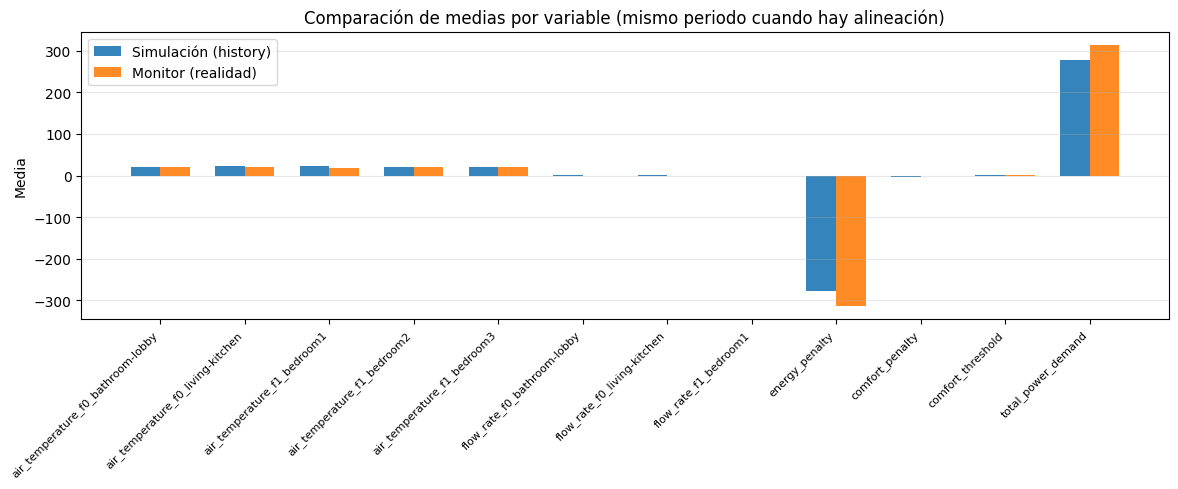

In [47]:
# Gráfico: comparación de medias (simulación vs realidad) para una selección de variables
if len(df_dist) == 0:
    print("No hay variables para comparar.")
else:
    # Seleccionar hasta 12 variables variadas (observations, actions, info)
    n_plot = min(12, len(df_dist))
    subset = df_dist.head(n_plot) if len(df_dist) <= 12 else pd.concat([
        df_dist[df_dist["origen"] == "observation"].head(5),
        df_dist[df_dist["origen"] == "action"].head(3),
        df_dist[df_dist["origen"] == "info"].head(4),
    ]).drop_duplicates().head(n_plot)
    if len(subset) == 0:
        subset = df_dist.head(n_plot)

    x = np.arange(len(subset))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, subset["sim_mean"], w, label="Simulación (history)", alpha=0.9)
    ax.bar(x + w/2, subset["mon_mean"], w, label="Monitor (realidad)", alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(subset["variable"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Media")
    ax.set_title("Comparación de medias por variable (mismo periodo cuando hay alineación)")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

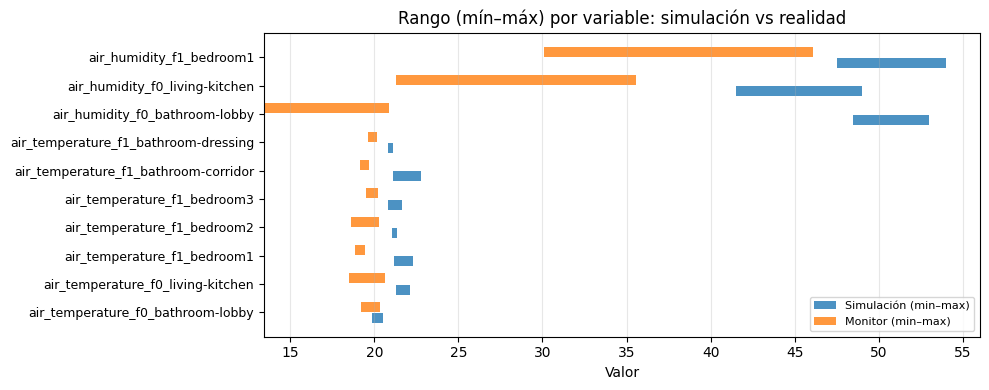

In [48]:
# Comparación mín / máximo por variable (barras de rango)
if len(df_dist) > 0:
    n_show = min(10, len(df_dist))
    sub = df_dist.head(n_show)
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(sub))
    ax.barh(x - 0.2, sub["sim_max"] - sub["sim_min"], left=sub["sim_min"], height=0.35, label="Simulación (min–max)", alpha=0.8, color="C0")
    ax.barh(x + 0.2, sub["mon_max"] - sub["mon_min"], left=sub["mon_min"], height=0.35, label="Monitor (min–max)", alpha=0.8, color="C1")
    ax.set_yticks(x)
    ax.set_yticklabels(sub["variable"], fontsize=9)
    ax.set_xlabel("Valor")
    ax.set_title("Rango (mín–máx) por variable: simulación vs realidad")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Conclusiones: variables que influyen en water/supply temp

En el **periodo comparativo** (2026-03-04 12:15:48 a 2026-03-05 08:17:47) se analiza qué variables correlacionan con la **temperatura de suministro** (`action/t_supply` en history, `water_temperature` en monitor), para identificar posibles factores que la determinan.

In [49]:
# Periodo comparativo
t_start = pd.Timestamp("2026-03-04 12:15:48.236082792")
t_end = pd.Timestamp("2026-03-05 08:17:47.552323103")

# History: filtrar por _timestamp
df_h = df_history.copy()
if "_datetime" not in df_h.columns:
    df_h["_datetime"] = pd.to_datetime(df_h["_timestamp"], unit="s")
mask_h = (df_h["_datetime"] >= t_start) & (df_h["_datetime"] <= t_end)
df_period_h = df_h.loc[mask_h].copy()

# Monitor: filtrar por (year, month, day, hour) en infos
if "_datetime" not in df_infos.columns:
    df_infos["_datetime"] = pd.to_datetime(
        dict(year=2026, month=df_infos["month"], day=df_infos["day"], hour=df_infos["hour"])
    )
mask_m = (df_infos["_datetime"] >= t_start) & (df_infos["_datetime"] <= t_end)
idx_m = df_infos.index[mask_m].tolist()
df_period_obs = df_obs.loc[df_obs.index.isin(idx_m)].copy()
df_period_infos = df_infos.loc[mask_m].copy()
df_period_actions = df_actions.loc[df_actions.index.isin(idx_m)].copy()

# Target: temperatura de suministro
target_hist = "action/t_supply"
target_mon = "water_temperature"
y_hist = df_period_h[target_hist]
y_mon = df_period_obs[target_mon] if target_mon in df_period_obs.columns else df_period_actions[target_mon]

print(f"Periodo: {t_start} a {t_end}")
print(f"Filas history en periodo: {len(df_period_h)}, monitor: {len(df_period_obs)}")

Periodo: 2026-03-04 12:15:48.236082792 a 2026-03-05 08:17:47.552323103
Filas history en periodo: 41, monitor: 40


### Estadísticas de correlación: t_supply / water_temperature vs observaciones

En el mismo periodo se calcula la **correlación de Pearson** entre la temperatura de suministro y cada variable del **conjunto de observaciones** (excluyendo flow_rate y water_temperature). Se muestran: coeficiente r, p-value y n (número de pares válidos).

In [50]:
from scipy import stats

# --- Solo variables de OBSERVACIÓN ---
# History: columnas observation/*
obs_cols_h = [c for c in df_period_h.columns if c.startswith("observation/")]
# Excluir si en algún lado no hay datos
obs_cols_h = [c for c in obs_cols_h if df_period_h[c].dtype in ("float64", "int64")]

# Monitor: observaciones (excluir water_temperature y flow_rate)
exclude_mon = [target_mon] + [c for c in df_period_obs.columns if "flow_rate" in c or c == "water_temperature"]
obs_cols_m = [c for c in df_period_obs.columns if c not in exclude_mon and pd.api.types.is_numeric_dtype(df_period_obs[c])]

def pearson_stats(x, y):
    """r, p-value y n para correlación de Pearson."""
    mask = ~(pd.isna(x) | pd.isna(y))
    n = mask.sum()
    if n < 3:
        return np.nan, np.nan, n
    r, p = stats.pearsonr(x.loc[mask], y.loc[mask])
    return r, p, n

# Correlación con t_supply (history) por cada observación en history
rows = []
for c in obs_cols_h:
    r, p, n = pearson_stats(df_period_h[c], y_hist)
    name_short = c.replace("observation/", "")
    rows.append({
        "variable": name_short,
        "origen": "history",
        "r": r,
        "p_value": p,
        "n": n,
    })

# Correlación con water_temperature (monitor) por cada observación en monitor
for c in obs_cols_m:
    r, p, n = pearson_stats(df_period_obs[c], y_mon)
    rows.append({
        "variable": c,
        "origen": "monitor",
        "r": r,
        "p_value": p,
        "n": n,
    })

df_corr_obs = pd.DataFrame(rows)
# Tabla por origen
print("=== SIMULACIÓN (history): t_supply vs observaciones ===\n")
df_h_obs = df_corr_obs[df_corr_obs["origen"] == "history"].sort_values("r", key=abs, ascending=False)
df_h_obs = df_h_obs[["variable", "r", "p_value", "n"]].round({"r": 4, "p_value": 4})
print(df_h_obs.to_string(index=False))
print("\n=== MONITOR (realidad): water_temperature vs observaciones ===\n")
df_m_obs = df_corr_obs[df_corr_obs["origen"] == "monitor"].sort_values("r", key=abs, ascending=False)
df_m_obs = df_m_obs[["variable", "r", "p_value", "n"]].round({"r": 4, "p_value": 4})
print(df_m_obs.to_string(index=False))

=== SIMULACIÓN (history): t_supply vs observaciones ===

                             variable       r  p_value  n
              diffuse_solar_radiation -0.8740   0.0000 41
               direct_solar_radiation -0.8654   0.0000 41
              air_temperature_f1_bed2 -0.8361   0.0000 41
                     outdoor_humidity  0.8030   0.0000 41
     air_temperature_f1_main_bathroom -0.7729   0.0000 41
                  outdoor_temperature -0.7493   0.0000 41
              air_temperature_f1_bed1 -0.7292   0.0000 41
                       wind_direction -0.7018   0.0000 41
                             hour_cos  0.6918   0.0000 41
                           wind_speed -0.6816   0.0000 41
   air_temperature_f0_livroom-kitchen -0.6066   0.0000 41
              air_temperature_f1_bed3 -0.5605   0.0001 41
air_temperature_f1_secondary_bathroom -0.4855   0.0013 41
      heat_pump_load_side_outlet_temp  0.4491   0.0032 41
             air_humidity_f0_bathroom -0.4280   0.0052 41
               

/tmp/ipykernel_7908/3327380873.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x.loc[mask], y.loc[mask])


In [51]:
# Tabla unificada: misma variable en simulación y monitor (usando OBS_MAPPING)
# history usa nombre "observation/xxx", monitor usa nombre mapeado
inv_obs_mapping = {v: k for k, v in OBS_MAPPING.items()}
combined_rows = []
for mon_var, hist_var in OBS_MAPPING.items():
    row_h = df_corr_obs[(df_corr_obs["origen"] == "history") & (df_corr_obs["variable"] == hist_var)]
    row_m = df_corr_obs[(df_corr_obs["origen"] == "monitor") & (df_corr_obs["variable"] == mon_var)]
    r_sim = row_h["r"].iloc[0] if len(row_h) else np.nan
    p_sim = row_h["p_value"].iloc[0] if len(row_h) else np.nan
    n_sim = row_h["n"].iloc[0] if len(row_h) else np.nan
    r_mon = row_m["r"].iloc[0] if len(row_m) else np.nan
    p_mon = row_m["p_value"].iloc[0] if len(row_m) else np.nan
    n_mon = row_m["n"].iloc[0] if len(row_m) else np.nan
    combined_rows.append({
        "variable (monitor)": mon_var,
        "r_sim": r_sim,
        "p_sim": p_sim,
        "n_sim": n_sim,
        "r_mon": r_mon,
        "p_mon": p_mon,
        "n_mon": n_mon,
    })
df_corr_combined = pd.DataFrame(combined_rows)
df_corr_combined["_abs_r_sim"] = df_corr_combined["r_sim"].abs()
df_corr_combined = df_corr_combined.sort_values("_abs_r_sim", ascending=False).drop(columns=["_abs_r_sim"])
print("Correlación t_supply/water_temperature vs observaciones (variables mapeadas, periodo comparativo):\n")
print(df_corr_combined.round(4).to_string(index=False))

Correlación t_supply/water_temperature vs observaciones (variables mapeadas, periodo comparativo):

                   variable (monitor)   r_sim  p_sim  n_sim   r_mon  p_mon  n_mon
              diffuse_solar_radiation -0.8740 0.0000   41.0 -0.3106 0.0511   40.0
               direct_solar_radiation -0.8654 0.0000   41.0 -0.1665 0.3044   40.0
                     outdoor_humidity  0.8030 0.0000   41.0  0.4504 0.0035   40.0
                  outdoor_temperature -0.7493 0.0000   41.0 -0.4393 0.0046   40.0
                       wind_direction -0.7018 0.0000   41.0 -0.2831 0.0767   40.0
                             hour_cos  0.6918 0.0000   41.0  0.5498 0.0002   40.0
                           wind_speed -0.6816 0.0000   41.0 -0.2359 0.1428   40.0
                              day_sin  0.4027 0.0091   41.0  0.4659 0.0024   40.0
                              day_cos -0.4027 0.0091   41.0 -0.4659 0.0024   40.0
                             hour_sin  0.1954 0.2209   41.0  0.3911 0.0126   40.

In [52]:
# Correlación con t_supply (history): usar solo observaciones e info, no otras acciones
exclude = [target_hist, "_timestamp", "_datetime", "_runtime", "_step", "reward"]
candidates_h = [c for c in df_period_h.columns if c not in exclude and df_period_h[c].dtype in ("float64", "int64")]
corr_hist = df_period_h[candidates_h].corrwith(y_hist).dropna().sort_values(key=abs, ascending=False)
print("=== HISTORY (simulación): correlación con action/t_supply en el periodo ===\n")
print(corr_hist.head(20).to_string())

=== HISTORY (simulación): correlación con action/t_supply en el periodo ===

info/t_supply                                     1.000000
observation/diffuse_solar_radiation              -0.874037
observation/direct_solar_radiation               -0.865428
observation/air_temperature_f1_bed2              -0.836129
action/valve_f0_livroom-kitchen                  -0.834468
observation/outdoor_humidity                      0.802963
info/comfort_term                                 0.776513
info/comfort_penalty                              0.776513
info/total_temperature_violation                 -0.776513
observation/air_temperature_f1_main_bathroom     -0.772858
observation/outdoor_temperature                  -0.749309
action/valve_f1_bed2                              0.740134
observation/air_temperature_f1_bed1              -0.729210
action/valve_f1_bed1                              0.705386
observation/wind_direction                       -0.701769
info/timestep                         

/usr/local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [53]:
# Correlación con water_temperature (monitor): observaciones + infos (excluir otras acciones para no mezclar causa)
exclude_m = [target_mon] + [c for c in df_period_obs.columns if "flow_rate" in c]
candidates_obs = [c for c in df_period_obs.columns if c not in exclude_m and pd.api.types.is_numeric_dtype(df_period_obs[c])]
corr_obs = df_period_obs[candidates_obs].corrwith(y_mon).dropna().sort_values(key=abs, ascending=False)
# Infos (alinear por índice: water_temperature viene de observations/actions con mismo index que infos en el periodo)
candidates_inf = [c for c in df_period_infos.columns if pd.api.types.is_numeric_dtype(df_period_infos[c])]
y_inf = y_mon.reindex(df_period_infos.index).dropna()
common_idx = y_inf.index.intersection(df_period_infos.index)
corr_inf = df_period_infos.loc[common_idx, candidates_inf].corrwith(y_inf.loc[common_idx]).dropna().sort_values(key=abs, ascending=False)
print("=== MONITOR (realidad): correlación con water_temperature en el periodo ===\n")
print("Observaciones (top 15):")
print(corr_obs.head(15).to_string())
print("\nInfos (top 10):")
print(corr_inf.head(10).to_string())

=== MONITOR (realidad): correlación con water_temperature en el periodo ===

Observaciones (top 15):
hour_cos                                    0.549799
plr_current                                 0.470843
heat_source_load_side_heat_transfer_rate    0.470843
heat_source_electricity_rate                0.470843
day_cos                                    -0.465943
day_sin                                     0.465943
air_humidity_f1_bedroom3                    0.465856
air_humidity_f1_bedroom1                    0.456882
outdoor_humidity                            0.450371
air_humidity_f1_bathroom-dressing           0.442637
outdoor_temperature                        -0.439283
air_temperature_f0_living-kitchen          -0.421715
air_humidity_f0_bathroom-lobby              0.410047
air_humidity_f1_bedroom2                    0.400389
air_humidity_f1_bathroom-corridor           0.396128

Infos (top 10):
energy_penalty                -0.470843
total_power_demand             0.470843
energy_

In [54]:
# Resumen unificado: variables con mayor |correlación| con water/supply temp
top_n = 15
combined = pd.DataFrame({
    "variable_history": corr_hist.head(top_n).index.tolist() + [""] * max(0, top_n - len(corr_hist)),
    "corr_history": list(corr_hist.head(top_n).values) + [np.nan] * max(0, top_n - len(corr_hist)),
})
# Mapear nombres monitor -> history para comparar
mon_to_hist = {v: k for k, v in {**OBS_MAPPING, **INFO_MAPPING}.items()}
mon_vars = list(corr_obs.head(8).index) + list(corr_inf.head(5).index)
combined_mon = pd.DataFrame({
    "variable_monitor": mon_vars[:top_n],
    "corr_monitor": [corr_obs.get(v, np.nan) if v in corr_obs.index else corr_inf.get(v, np.nan) for v in mon_vars[:top_n]],
})
print("Top variables asociadas a water/supply temp en el periodo:")
display_df = pd.DataFrame({
    "Simulación (history)": corr_hist.head(10).index.tolist(),
    "Corr (sim)": corr_hist.head(10).values.round(3).tolist(),
})
print(display_df.to_string(index=False))

Top variables asociadas a water/supply temp en el periodo:
                        Simulación (history)  Corr (sim)
                               info/t_supply       1.000
         observation/diffuse_solar_radiation      -0.874
          observation/direct_solar_radiation      -0.865
         observation/air_temperature_f1_bed2      -0.836
             action/valve_f0_livroom-kitchen      -0.834
                observation/outdoor_humidity       0.803
                           info/comfort_term       0.777
                        info/comfort_penalty       0.777
            info/total_temperature_violation      -0.777
observation/air_temperature_f1_main_bathroom      -0.773


### Conclusiones (periodo 2026-03-04 12:15 — 2026-03-05 08:17)

A partir de las correlaciones en el periodo comparativo, las variables que **pueden estar influyendo en water/supply temp** son:

1. **Variables de demanda térmica / confort**
   - **Setpoints de calefacción** (`setpoint_*` / `heating_setpoint_*`): la temperatura de consigna de cada zona condiciona la demanda; a mayor consigna o mayor desviación respecto al ambiente, el sistema suele subir la temperatura de suministro.
   - **Temperaturas de aire por zona** (`air_temperature_*`): cuando las temperaturas interiores se alejan del setpoint (frío), el control suele aumentar la temperatura de suministro para recuperar confort.

2. **Variables del generador (bomba de calor)**
   - **heat_pump_load_side_outlet_temp** / **heat_source_load_side_outlet_temp**: salida del generador; está muy ligada a la temperatura de suministro (es la fuente del agua que se envía al circuito).
   - **heat_pump_electricity_rate** / **heat_source_electricity_rate**: potencia eléctrica del generador; refleja carga y suele correlacionar con una mayor temperatura de suministro cuando hay más demanda.

3. **Variables climáticas**
   - **outdoor_temperature**: en estrategias de compensación climática, la temperatura de suministro se ajusta en función de la temperatura exterior (más frío exterior → mayor temperatura de suministro).
   - **wind_speed**, **solar radiation** (direct/diffuse): pueden influir en la carga del edificio y, de forma indirecta, en la decisión del control sobre la temperatura de suministro.

4. **Variables de penalización / objetivo del agente**
   - **energy_term**, **total_power_demand**, **comfort_term**, **comfort_penalty**: en un control por refuerzo, el agente modula la temperatura de suministro para equilibrar confort y consumo; estas variables reflejan ese equilibrio y pueden correlacionar con `t_supply`/`water_temperature`.

**Recomendación:** Revisar en las tablas anteriores las variables con mayor |correlación| en **simulación** y en **monitor** para este periodo. Si las mismas variables destacan en ambos, es plausible que sean los principales factores que influyen en water/supply temp; si difieren, puede haber diferencias de modelo o de estrategia de control entre simulación y realidad.

## 8. Resumen: coincidencia de variables

Tabla resumen de qué variables del history tienen equivalente en monitor y viceversa.

In [55]:
rows = []
for h_name, m_name in OBS_MAPPING.items():
    in_hist = f"observation/{h_name}" in df_history.columns
    in_mon = m_name in df_obs.columns
    rows.append({"tipo": "observation", "history": h_name, "monitor": m_name, "en_history": in_hist, "en_monitor": in_mon})
for h_name, m_name in ACTION_MAPPING.items():
    in_hist = f"action/{h_name}" in df_history.columns
    in_mon = m_name in df_actions.columns
    rows.append({"tipo": "action", "history": h_name, "monitor": m_name, "en_history": in_hist, "en_monitor": in_mon})
for h_name, m_name in INFO_MAPPING.items():
    in_hist = f"info/{h_name}" in df_history.columns
    in_mon = m_name in df_infos.columns
    rows.append({"tipo": "info", "history": h_name, "monitor": m_name, "en_history": in_hist, "en_monitor": in_mon})

summary = pd.DataFrame(rows)
print(summary.to_string())
print("\nVariables en ambos:", (summary["en_history"] & summary["en_monitor"]).sum())

           tipo                                history                                monitor  en_history  en_monitor
0   observation            air_temperature_f0_bathroom      air_temperature_f0_bathroom-lobby        True        True
1   observation     air_temperature_f0_livroom-kitchen      air_temperature_f0_living-kitchen        True        True
2   observation                air_temperature_f1_bed1            air_temperature_f1_bedroom1        True        True
3   observation                air_temperature_f1_bed2            air_temperature_f1_bedroom2        True        True
4   observation                air_temperature_f1_bed3            air_temperature_f1_bedroom3        True        True
5   observation       air_temperature_f1_main_bathroom   air_temperature_f1_bathroom-corridor        True        True
6   observation  air_temperature_f1_secondary_bathroom   air_temperature_f1_bathroom-dressing        True        True
7   observation               air_humidity_f0_bathroom  